In [59]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [60]:
# Group files by (date, network) — one figure set per run-day per network.
# Handles both old YYYY-MM-DD and new YYYY-MM-DD_HHMMSS filename prefixes.
# Within a group, picks the most recent file per alpha (timestamp sort).
from collections import defaultdict

def _parse_date_network(path):
    stem = os.path.basename(path).replace('.npz', '')
    date = stem[:10]  # YYYY-MM-DD is always the first 10 chars
    # rest = stem[18:] if (len(stem) > 17 and stem[10] == '_' and stem[11:17].isdigit()) else stem[11:]
    # network = rest.split('_kernel_alpha_')[0]
    network = stem.split('_kernel_alpha_')[0][11:]  # skip date + underscore
    return date, network

_all_kernel = glob.glob('Files/vacc/*_kernel_alpha_*.npz')
if not _all_kernel:
    raise FileNotFoundError("No kernel sweep files found in Files/vacc/")

all_combos = sorted(set(_parse_date_network(f) for f in _all_kernel))
print(f'Found {len(all_combos)} (date, network) combination(s):')

all_data = {}
for DATE, NETWORK in all_combos:
    label = f'{DATE}_{NETWORK}'

    by_alpha = defaultdict(list)
    for f in glob.glob(f'Files/vacc/{DATE}*_{NETWORK}_kernel_alpha_*.npz'):
        by_alpha[float(np.load(f)['alpha'])].append(f)

    runs = []
    for alpha in sorted(by_alpha):
        f = sorted(by_alpha[alpha])[-1]
        d = np.load(f)
        runs.append({
            'alpha': float(d['alpha']),
            'delta': d['delta'],
            'I_low': d['I_low'],
            'I_high': d['I_high'],
            'lam': d['lam_grid'],
            'nu': d['nu_grid'],
        })

    baseline_candidates = sorted(glob.glob(f'Files/vacc/{DATE}*_{NETWORK}_baseline.npz'))
    has_baseline = len(baseline_candidates) > 0
    bd = np.load(baseline_candidates[-1]) if has_baseline else None

    all_data[label] = {'runs': runs, 'has_baseline': has_baseline, 'bd': bd,
                       'date': DATE, 'network': NETWORK}

    print(f'\n  {label}')
    print(f'  Loaded {len(runs)} kernel files' + (' + baseline' if has_baseline else ' (no baseline)'))
    for r in runs:
        n_bi = int((r['delta'] > 0.05).sum())
        print(f'    alpha={r["alpha"]:5.1f}  max_delta={r["delta"].max():.4f}  bistable_cells(>0.05)={n_bi}')

Found 2 (date, network) combination(s):

  2026-05-03_Synthetic_poisson_k5
  Loaded 13 kernel files + baseline
    alpha=  0.1  max_delta=0.5694  bistable_cells(>0.05)=140
    alpha=  0.2  max_delta=0.4249  bistable_cells(>0.05)=100
    alpha=  0.3  max_delta=0.2143  bistable_cells(>0.05)=66
    alpha=  0.6  max_delta=0.1007  bistable_cells(>0.05)=30
    alpha=  1.0  max_delta=0.0694  bistable_cells(>0.05)=8
    alpha=  1.8  max_delta=0.0361  bistable_cells(>0.05)=0
    alpha=  3.2  max_delta=0.0126  bistable_cells(>0.05)=0
    alpha=  5.6  max_delta=0.0098  bistable_cells(>0.05)=0
    alpha= 10.0  max_delta=0.0063  bistable_cells(>0.05)=0
    alpha= 17.8  max_delta=0.0076  bistable_cells(>0.05)=0
    alpha= 31.6  max_delta=0.0047  bistable_cells(>0.05)=0
    alpha= 56.2  max_delta=0.0043  bistable_cells(>0.05)=0
    alpha=100.0  max_delta=0.0043  bistable_cells(>0.05)=0

  2026-05-03_Thiers13
  Loaded 11 kernel files + baseline
    alpha=  0.1  max_delta=0.1876  bistable_cells(>0.05)=

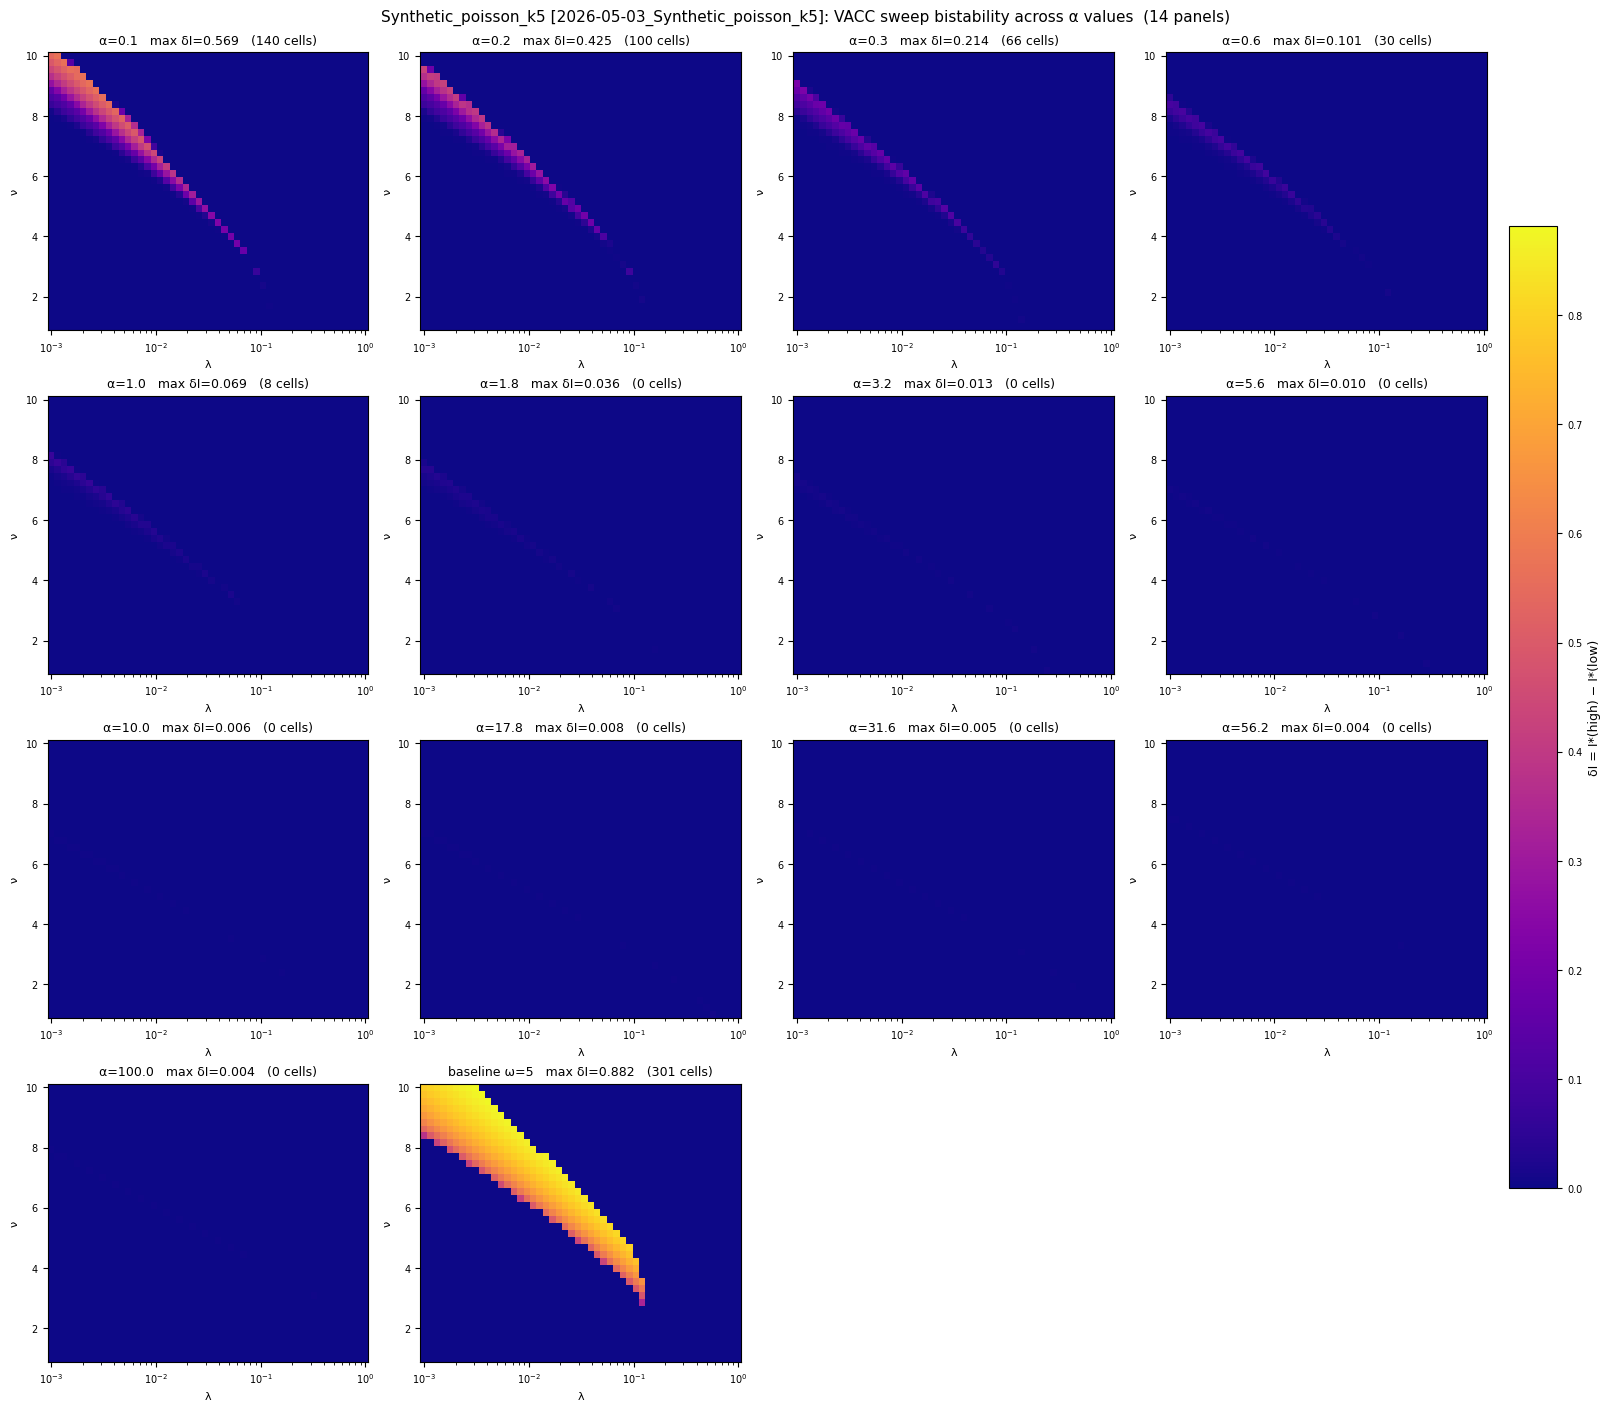

Saved → figures/2026-05-03_Synthetic_poisson_k5_vacc_sweep_alpha_grid.png


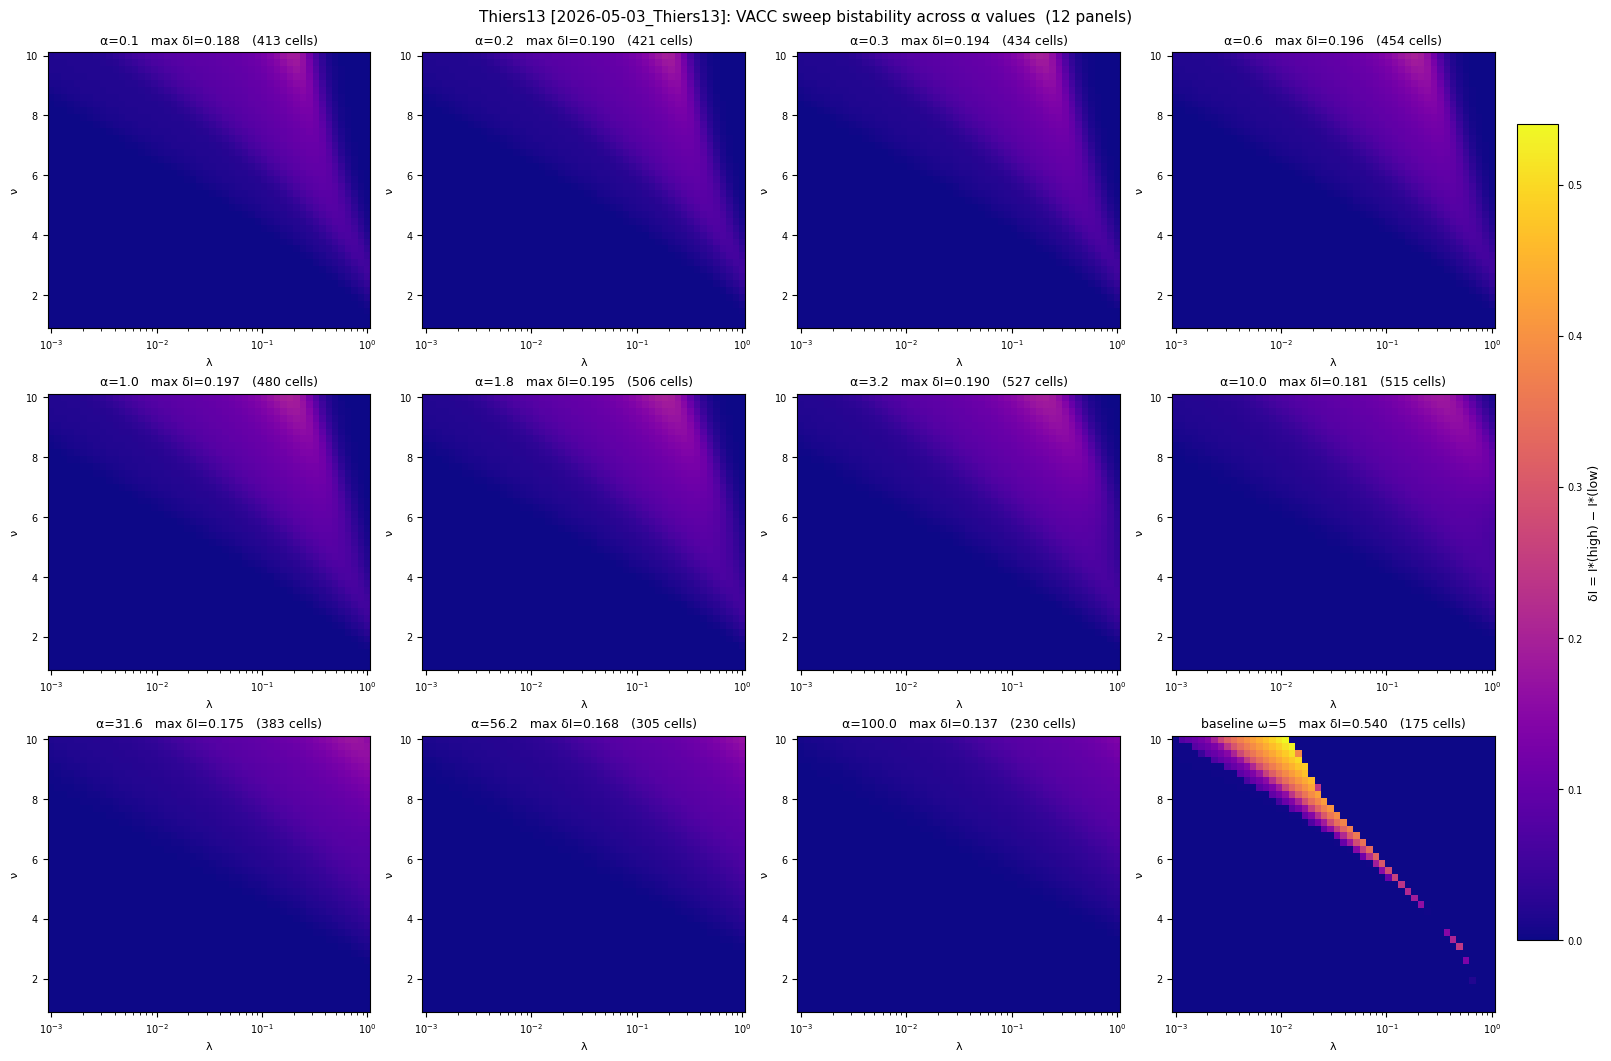

Saved → figures/2026-05-03_Thiers13_vacc_sweep_alpha_grid.png


In [61]:
# --- Alpha-grid heatmap (one figure per date+network) ---
for label, data in all_data.items():
    runs = data['runs']
    has_baseline = data['has_baseline']
    bd = data['bd']
    NETWORK = data['network']

    n_panels = len(runs) + (1 if has_baseline else 0)
    ncols = 4
    nrows = (n_panels + ncols - 1) // ncols

    vmax = max(r['delta'].max() for r in runs)
    if has_baseline:
        vmax = max(vmax, float(bd['delta'].max()))

    fig, axes_grid = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows),
                                   constrained_layout=True, squeeze=False)
    axes = axes_grid.flatten()

    last_im = None
    for idx, run in enumerate(runs):
        ax = axes[idx]
        delta = run['delta'].T
        lam, nu = run['lam'], run['nu']
        im = ax.pcolormesh(lam, nu, delta, vmin=0, vmax=vmax, cmap='plasma', shading='auto')
        ax.set_xscale('log')
        last_im = im
        n_bi = int((run['delta'] > 0.05).sum())
        ax.set_title(f'α={run["alpha"]:.1f}   max δI={run["delta"].max():.3f}   ({n_bi} cells)', fontsize=9)
        ax.set_xlabel('λ', fontsize=8)
        ax.set_ylabel('ν', fontsize=8)
        ax.tick_params(labelsize=7)

    if has_baseline:
        ax = axes[len(runs)]
        delta_b = bd['delta'].T
        lam_b, nu_b = bd['lam_grid'], bd['nu_grid']
        im = ax.pcolormesh(lam_b, nu_b, delta_b, vmin=0, vmax=vmax, cmap='plasma', shading='auto')
        ax.set_xscale('log')
        last_im = im
        n_bi_b = int((bd['delta'] > 0.05).sum())
        ax.set_title(f'baseline ω=5   max δI={float(bd["delta"].max()):.3f}   ({n_bi_b} cells)', fontsize=9)
        ax.set_xlabel('λ', fontsize=8)
        ax.set_ylabel('ν', fontsize=8)
        ax.tick_params(labelsize=7)

    for idx in range(n_panels, len(axes)):
        axes[idx].set_visible(False)

    cbar = fig.colorbar(last_im, ax=axes_grid[:, -1].tolist(), shrink=0.85)
    cbar.set_label('δI = I*(high) − I*(low)', fontsize=9)
    cbar.ax.tick_params(labelsize=7)

    fig.suptitle(f'{NETWORK} [{label}]: VACC sweep bistability across α values  ({n_panels} panels)', fontsize=11)
    outpath = f'figures/{label}_vacc_sweep_alpha_grid.png'
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {outpath}')

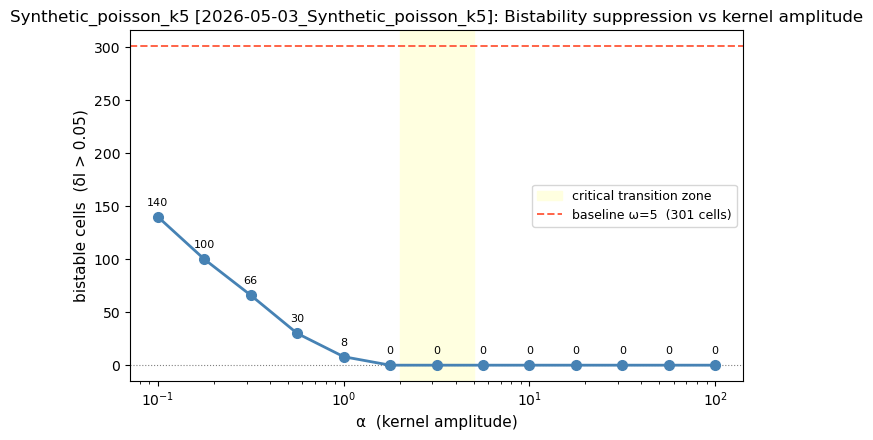

Saved → figures/2026-05-03_Synthetic_poisson_k5_bistable_count_vs_alpha.png


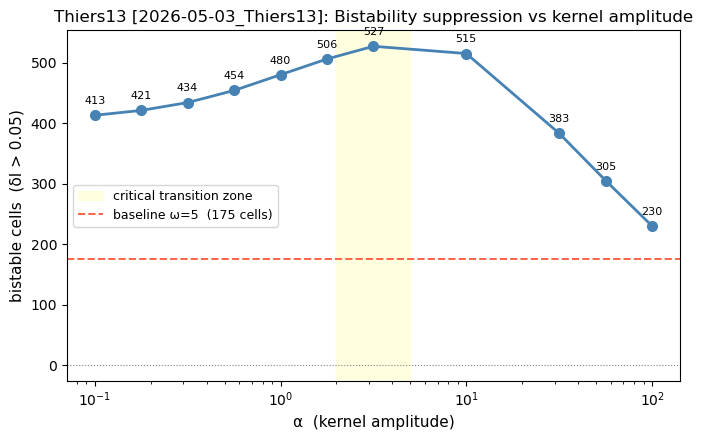

Saved → figures/2026-05-03_Thiers13_bistable_count_vs_alpha.png


In [62]:
# --- Bistable-cell count vs alpha (one figure per date+network) ---
for label, data in all_data.items():
    runs = data['runs']
    has_baseline = data['has_baseline']
    bd = data['bd']
    NETWORK = data['network']

    alphas = [r['alpha'] for r in runs]
    counts = [int((r['delta'] > 0.05).sum()) for r in runs]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.axvspan(2, 5, color='lightyellow', zorder=0, label='critical transition zone')

    if has_baseline:
        n_bi_b = int((bd['delta'] > 0.05).sum())
        ax.axhline(n_bi_b, color='tomato', linestyle='--', linewidth=1.4,
                   label=f'baseline ω=5  ({n_bi_b} cells)', zorder=1)

    ax.plot(alphas, counts, 'o-', color='steelblue', linewidth=2, markersize=7, zorder=2)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, zorder=1)

    for a, c in zip(alphas, counts):
        ax.annotate(str(c), (a, c), textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8)

    ax.set_xlabel('α  (kernel amplitude)', fontsize=11)
    ax.set_ylabel('bistable cells  (δI > 0.05)', fontsize=11)
    ax.set_title(f'{NETWORK} [{label}]: Bistability suppression vs kernel amplitude', fontsize=12)
    ax.set_xscale('log')
    ax.legend(fontsize=9, framealpha=0.8)
    plt.tight_layout()
    outpath = f'figures/{label}_bistable_count_vs_alpha.png'
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {outpath}')

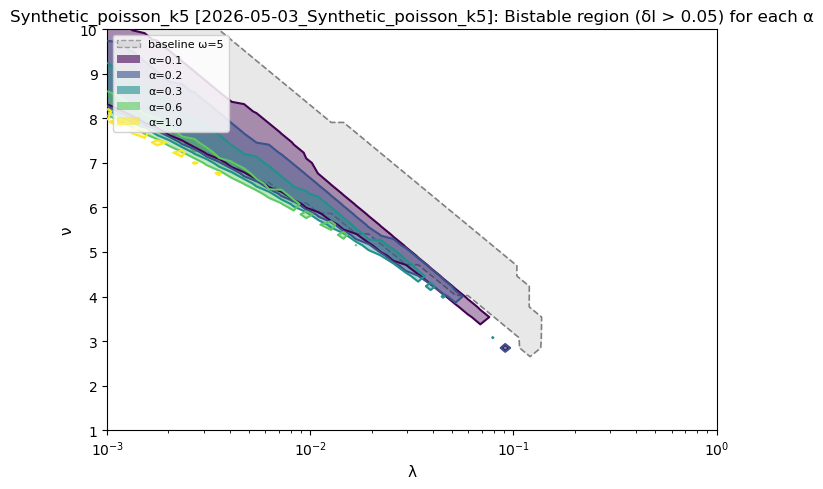

Saved → figures/2026-05-03_Synthetic_poisson_k5_bistable_region_overlay.png


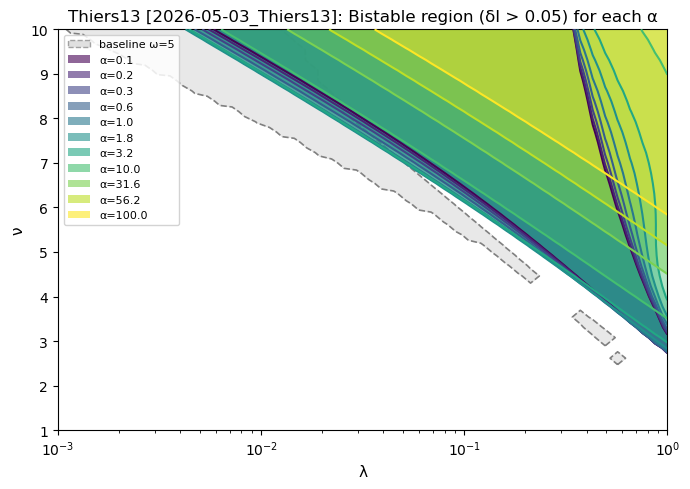

Saved → figures/2026-05-03_Thiers13_bistable_region_overlay.png


In [63]:
# --- Bistable region overlay (one figure per date+network) ---
from matplotlib.patches import Patch

for label, data in all_data.items():
    runs = data['runs']
    has_baseline = data['has_baseline']
    bd = data['bd']
    NETWORK = data['network']

    bistable_runs = [r for r in runs if r['delta'].max() > 0.05]
    cmap_k = plt.cm.viridis
    colors = [cmap_k(i / max(len(bistable_runs) - 1, 1)) for i in range(len(bistable_runs))]

    fig, ax = plt.subplots(figsize=(7, 5))

    if has_baseline:
        delta_b = bd['delta'].T
        lam_b, nu_b = bd['lam_grid'], bd['nu_grid']
        ax.contourf(lam_b, nu_b, delta_b,
                    levels=[0.05, delta_b.max() + 0.01],
                    colors=['lightgray'], alpha=0.5, zorder=0)
        ax.contour(lam_b, nu_b, delta_b,
                   levels=[0.05], colors=['gray'], linewidths=1.2,
                   linestyles='--', zorder=1)

    for run, color in zip(bistable_runs, colors):
        lam, nu = run['lam'], run['nu']
        delta = run['delta'].T
        ax.contourf(lam, nu, delta,
                    levels=[0.05, delta.max() + 0.01],
                    colors=[color], alpha=0.4, zorder=2)
        ax.contour(lam, nu, delta,
                   levels=[0.05], colors=[color], linewidths=1.5, zorder=3)

    handles = [Patch(facecolor='lightgray', edgecolor='gray', linestyle='--',
                     alpha=0.7, label='baseline ω=5')]
    handles += [
        Patch(facecolor=colors[i], alpha=0.6, label=f'α={bistable_runs[i]["alpha"]:.1f}')
        for i in range(len(bistable_runs))
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper left', framealpha=0.85)
    ax.set_xscale('log')
    ax.set_xlabel('λ', fontsize=11)
    ax.set_ylabel('ν', fontsize=11)
    ax.set_title(f'{NETWORK} [{label}]: Bistable region (δI > 0.05) for each α', fontsize=12)
    plt.tight_layout()
    outpath = f'figures/{label}_bistable_region_overlay.png'
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {outpath}')

## Ridgeline analysis — group-state distributions at stationarity

For each network, we pick the (λ, ν) cell with the highest bistability indicator δI, then re-run the ODE at two contrasting α values (most bistable vs. least bistable) and two initial conditions (I₀ low / high).

The 2×2 ridgeline grid shows fₙᵢ at stationarity. In the bistable row the two panels should look *different* (the system lands in different group-state attractors); in the flat row they should converge to the *same* distribution — directly illustrating the mechanistic consequence of bistability.

In [64]:
import json
from scipy.stats import binom
from scipy.integrate import solve_ivp


def load_group_statistics(network, path="Data/group_statistics.txt"):
    with open(path, "r") as f:
        results = json.load(f)
    data = results[network]
    n_vals, p_vals = data["group_size_n"], data["group_size_p"]
    k_vals, g_vals = data["membership_k"], data["membership_g"]
    nmax = int(max(n_vals))
    mmax = int(max(k_vals))
    pn = np.zeros(nmax + 1)
    gm = np.zeros(mmax + 1)
    for n, p in zip(n_vals, p_vals):
        pn[int(n)] = float(p)
    for k, g in zip(k_vals, g_vals):
        gm[int(k)] = float(g)
    state_meta = _get_state_meta(mmax, nmax, gm, pn)
    return gm, pn, mmax, nmax, state_meta


def _get_state_meta(mmax, nmax, gm, pn):
    m = np.arange(0, mmax + 1)
    imat = np.zeros((nmax + 1, nmax + 1))
    nmat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        imat[n, :n + 1] = np.arange(n + 1)
        nmat[n, :n + 1] = n
    pnmat = np.outer(pn, np.ones(nmax + 1))
    return (mmax, nmax, m, np.array(gm), np.array(pn), imat, nmat, pnmat)


def _infection_matrix(lam, nu, nmax):
    inf_mat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        for i in range(n):
            inf_mat[n, i] = lam * i ** nu
    return inf_mat


def _switching_matrix(w_func, nmax, args=()):
    w_mat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        for i in range(n + 1):
            w_mat[n, i] = w_func(n, i, *args)
    return w_mat


def _initialize(state_meta, I0):
    mmax, nmax = state_meta[0], state_meta[1]
    sm = np.full(mmax + 1, 1.0 - I0)
    fni = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        fni[n, :n + 1] = binom.pmf(np.arange(n + 1), n, I0)
    return sm, fni


def _infected_fraction(sm, gm):
    return float(np.sum((1.0 - sm) * gm))


def _vector_field(v, t, inf_mat, w_mat, state_meta, mu):
    mmax, nmax = state_meta[0], state_meta[1]
    m, gm, pn = state_meta[2], state_meta[3], state_meta[4]
    imat, nmat, pnmat = state_meta[5], state_meta[6], state_meta[7]

    sm  = v[:mmax + 1]
    fni = v[mmax + 1:].reshape((nmax + 1, nmax + 1))

    denom_r = np.sum((nmat[2:] - imat[2:]) * fni[2:] * pnmat[2:])
    r = (np.sum(inf_mat[2:] * (nmat[2:] - imat[2:]) * fni[2:] * pnmat[2:]) / denom_r
         if denom_r > 1e-14 else 0.0)

    denom_rho = np.sum(m * sm * gm)
    rho = (r * np.sum(m * (m - 1) * sm * gm) / denom_rho
           if denom_rho > 1e-14 else 0.0)

    I = _infected_fraction(sm, gm)

    S_w_denom = np.sum(nmat[2:] * w_mat[2:] * fni[2:] * pnmat[2:])
    S_w = (np.sum((nmat[2:] - imat[2:]) * w_mat[2:] * fni[2:] * pnmat[2:]) / S_w_denom
           if S_w_denom > 1e-14 else 1.0 - I)

    sm_field = mu * (1.0 - sm) - sm * m * r

    fni_field = np.zeros_like(fni)
    fni_field[2:, :nmax] += imat[2:, 1:] * (mu + w_mat[2:, 1:] * S_w) * fni[2:, 1:]
    fni_field[2:] += (
        -imat[2:] * (mu + w_mat[2:] * S_w)
        - (nmat[2:] - imat[2:]) * (inf_mat[2:] + rho + w_mat[2:] * (1.0 - S_w))
    ) * fni[2:]
    fni_field[2:, 1:nmax + 1] += (
        (nmat[2:, :nmax] - imat[2:, :nmax])
        * (inf_mat[2:, :nmax] + rho + w_mat[2:, :nmax] * (1.0 - S_w))
        * fni[2:, :nmax]
    )
    return np.concatenate((sm_field, fni_field.reshape((nmax + 1) ** 2)))


def w_diversity_tension(n, i, alpha):
    phi = i / n
    return alpha * 4 * phi * (1 - phi)


def run_to_stationarity(lam, nu, alpha, gm, state_meta, mmax, nmax, mu, I0,
                         traj_points=3000, t_max=300.0):
    inf_mat = _infection_matrix(lam, nu, nmax)
    w_mat   = _switching_matrix(w_diversity_tension, nmax, args=(alpha,))
    sm, fni = _initialize(state_meta, I0)
    v0 = np.concatenate((sm, fni.reshape((nmax + 1) ** 2)))
    t  = np.linspace(0.0, t_max, traj_points)
    sol = solve_ivp(
        lambda time, state: _vector_field(state, time, inf_mat, w_mat, state_meta, mu),
        t_span=(t[0], t[-1]), y0=v0, method="LSODA", t_eval=t,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    v_final  = sol.y[:, -1]
    sm_final = v_final[:mmax + 1]
    fni_final = v_final[mmax + 1:].reshape((nmax + 1, nmax + 1))
    I_final  = _infected_fraction(sm_final, gm)
    return fni_final, I_final


print("Model utilities loaded.")

Model utilities loaded.


In [65]:
# For each (date, network) combo, pick the (lam, nu) cell with the highest δI
# under the most bistable alpha, then pair it with the least bistable alpha as contrast.

ridge_configs = {}

for label, data in all_data.items():
    runs   = data['runs']
    NETWORK = data['network']

    # rank runs by bistable cell count
    ranked = sorted(runs, key=lambda r: int((r['delta'] > 0.05).sum()), reverse=True)
    bistable_run = ranked[0]
    flat_run     = ranked[-1]

    # (lam_idx, nu_idx) of the peak δI cell in the most bistable run
    peak_idx = np.unravel_index(bistable_run['delta'].argmax(), bistable_run['delta'].shape)
    lam_star = float(bistable_run['lam'][peak_idx[0]])
    nu_star  = float(bistable_run['nu'][peak_idx[1]])

    ridge_configs[label] = {
        'network':       NETWORK,
        'lam':           lam_star,
        'nu':            nu_star,
        'alpha_bistable': bistable_run['alpha'],
        'alpha_flat':     flat_run['alpha'],
        'delta_peak':    float(bistable_run['delta'][peak_idx]),
    }
    print(
        f"{NETWORK}: lam={lam_star:.3e}  nu={nu_star:.2f}  "
        f"α_bistable={bistable_run['alpha']}  α_flat={flat_run['alpha']}  "
        f"δI_peak={float(bistable_run['delta'][peak_idx]):.3f}"
    )

Synthetic_poisson_k5: lam=1.151e-03  nu=10.00  α_bistable=0.09999999999999999  α_flat=100.0  δI_peak=0.569
Thiers13: lam=2.121e-01  nu=10.00  α_bistable=3.162277660168379  α_flat=100.0  δI_peak=0.190


In [66]:
import time as _time

MU_RIDGE    = 1.0
TRAJ_POINTS = 3000
T_MAX       = 300.0
I0_LOW      = 1e-3
I0_HIGH     = 0.99

ridge_results = {}

for label, cfg in ridge_configs.items():
    NETWORK = cfg['network']
    gm, pn, mmax, nmax, state_meta = load_group_statistics(NETWORK)

    results = {}
    for alpha_tag, alpha in [('bistable', cfg['alpha_bistable']),
                              ('flat',     cfg['alpha_flat'])]:
        for i0_tag, I0 in [('low', I0_LOW), ('high', I0_HIGH)]:
            print(f"  {NETWORK}  α={alpha}  I0={I0}...", end=' ', flush=True)
            t0 = _time.time()
            fni_final, I_final = run_to_stationarity(
                lam=cfg['lam'], nu=cfg['nu'], alpha=alpha,
                gm=gm, state_meta=state_meta, mmax=mmax, nmax=nmax,
                mu=MU_RIDGE, I0=I0,
                traj_points=TRAJ_POINTS, t_max=T_MAX,
            )
            print(f"I*={I_final:.4f}  ({_time.time()-t0:.1f}s)")
            results[(alpha_tag, i0_tag)] = {'fni_final': fni_final, 'I_final': I_final}

    ridge_results[label] = {'cfg': cfg, 'results': results, 'nmax': nmax}

print("All integrations complete.")

  Synthetic_poisson_k5  α=0.09999999999999999  I0=0.001... I*=0.5784  (0.3s)
  Synthetic_poisson_k5  α=0.09999999999999999  I0=0.99... I*=0.5784  (0.2s)
  Synthetic_poisson_k5  α=100.0  I0=0.001... I*=0.1566  (0.2s)
  Synthetic_poisson_k5  α=100.0  I0=0.99... I*=0.1566  (0.2s)
  Thiers13  α=3.162277660168379  I0=0.001... I*=0.2478  (0.2s)
  Thiers13  α=3.162277660168379  I0=0.99... I*=0.2481  (0.2s)
  Thiers13  α=100.0  I0=0.001... I*=0.0780  (0.2s)
  Thiers13  α=100.0  I0=0.99... I*=0.0936  (0.3s)
All integrations complete.


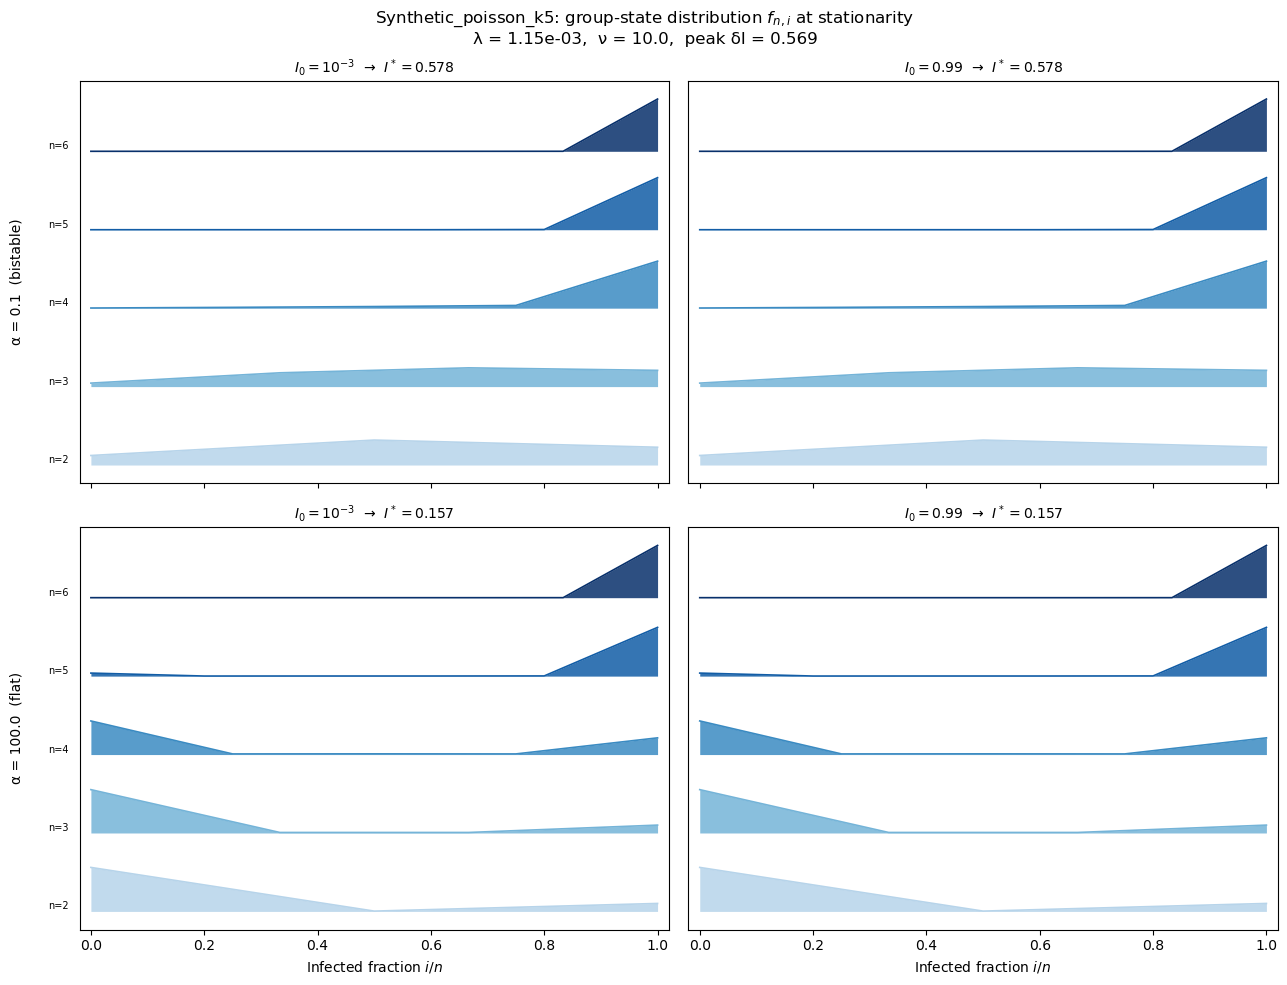

Saved → figures/2026-05-03_Synthetic_poisson_k5_ridgeline_stationary.png


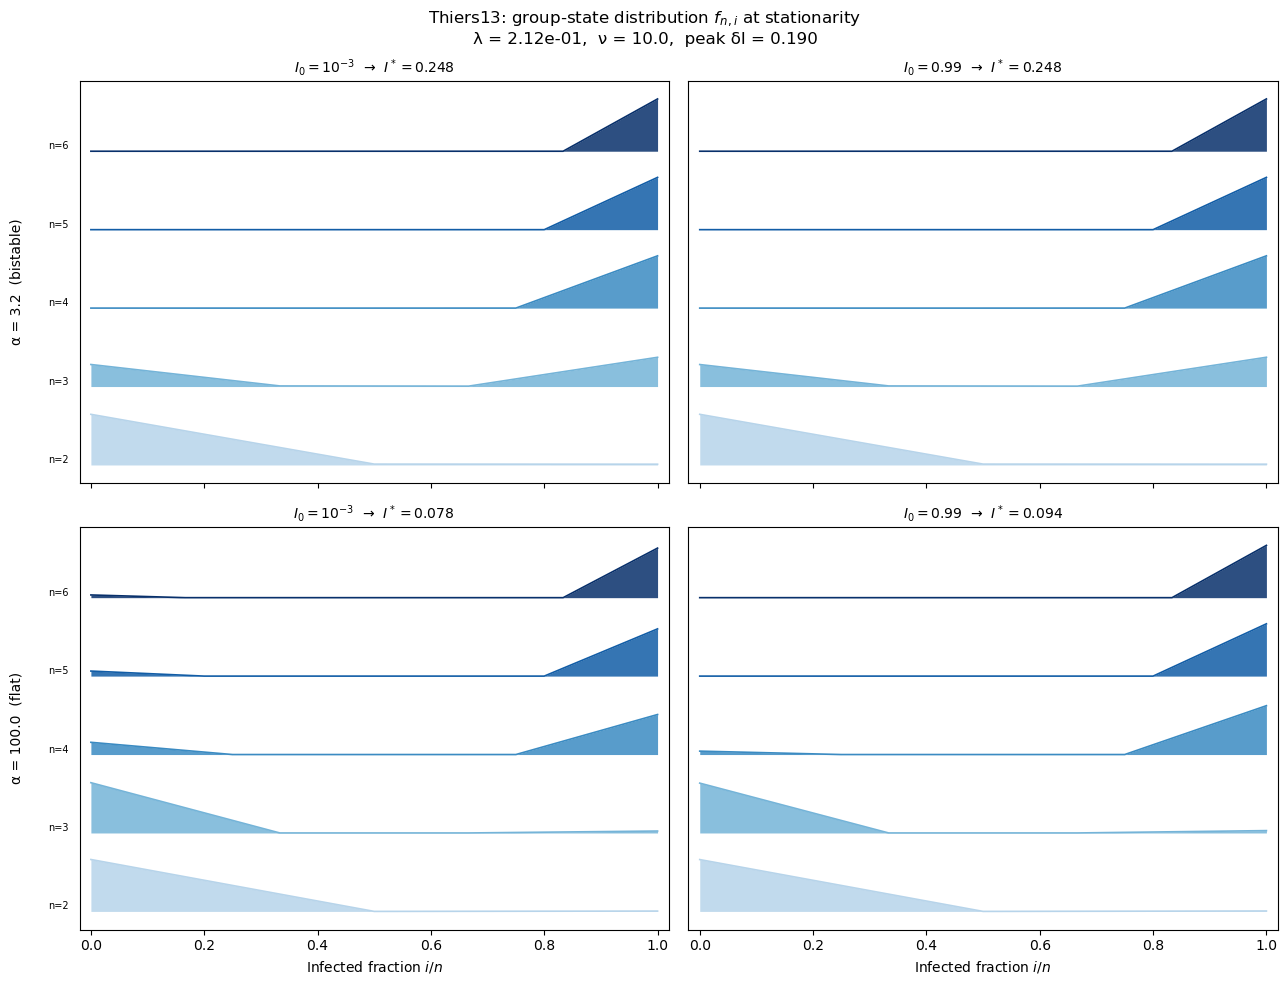

Saved → figures/2026-05-03_Thiers13_ridgeline_stationary.png


In [67]:
from datetime import datetime as _dt

_TIMESTAMP = _dt.now().strftime("%Y-%m-%d")

for label, data in ridge_results.items():
    cfg     = data['cfg']
    results = data['results']
    nmax    = data['nmax']
    NETWORK = cfg['network']

    # which group sizes to show (up to ~8 evenly spaced, always include nmax)
    step   = max(1, nmax // 8)
    n_show = list(range(2, nmax + 1, step))
    if nmax not in n_show:
        n_show.append(nmax)
    n_show = sorted(n_show)

    spacing = 1.5
    cmap    = plt.get_cmap("Blues")
    colors  = [cmap(0.3 + 0.7 * k / max(len(n_show) - 1, 1)) for k in range(len(n_show))]

    fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True, sharex=True)

    panel_order = [
        ('bistable', 'low',  0, 0),
        ('bistable', 'high', 0, 1),
        ('flat',     'low',  1, 0),
        ('flat',     'high', 1, 1),
    ]

    for a_tag, i0_tag, row, col in panel_order:
        ax      = axes[row, col]
        res     = results[(a_tag, i0_tag)]
        fni     = res['fni_final']
        I_final = res['I_final']
        alpha   = cfg['alpha_bistable'] if a_tag == 'bistable' else cfg['alpha_flat']
        i0_label = f"$I_0 = 10^{{-3}}$" if i0_tag == 'low' else f"$I_0 = 0.99$"

        for k, n0 in enumerate(n_show):
            phi_vals = np.arange(n0 + 1) / n0
            dist     = fni[n0, :n0 + 1].copy()
            total    = dist.sum()
            if total > 1e-14:
                dist /= total
            base = k * spacing
            ax.fill_between(phi_vals, base, base + dist,
                            alpha=0.85, color=colors[k], linewidth=0)
            ax.plot(phi_vals, base + dist, color=colors[k], lw=1.2)
            if col == 0:
                ax.text(-0.04, base, f"n={n0}", ha='right', va='bottom', fontsize=7)

        ax.set_xlim(-0.02, 1.02)
        ax.set_yticks([])
        ax.set_title(f"{i0_label}  →  $I^* = {I_final:.3f}$", fontsize=10)

        if row == 1:
            ax.set_xlabel(r"Infected fraction $i/n$", fontsize=10)

        # row label on the left panel
        if col == 0:
            row_label = (
                f"α = {alpha:.1f}  (bistable)"
                if a_tag == 'bistable'
                else f"α = {alpha:.1f}  (flat)"
            )
            ax.set_ylabel(row_label, fontsize=10, labelpad=40)

    fig.suptitle(
        f"{NETWORK}: group-state distribution $f_{{n,i}}$ at stationarity\n"
        f"λ = {cfg['lam']:.2e},  ν = {cfg['nu']:.1f},  "
        f"peak δI = {cfg['delta_peak']:.3f}",
        fontsize=12,
    )
    plt.tight_layout()
    outpath = f"figures/{_TIMESTAMP}_{NETWORK}_ridgeline_stationary.png"
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {outpath}")